In [1]:
import os
os.listdir('.')

['M.npy',
 '.config',
 'memory',
 '.prompts',
 'ci_low.npy',
 'Sk_im.npy',
 'ci_high.npy',
 'absD_peaks.npy',
 'Sk_re.npy',
 't_peaks.npy',
 '.kernel_llm_logs_1.txt',
 ' v6 — Binding Context Document.pdf']

In [2]:
import numpy as np
M = np.load('M.npy')
Sk_re = np.load('Sk_re.npy')
Sk_im = np.load('Sk_im.npy')
t_peaks = np.load('t_peaks.npy')
absD = np.load('absD_peaks.npy')
ci_low = np.load('ci_low.npy')
ci_high = np.load('ci_high.npy')
print("M shape:", M.shape)
print("Sk_re shape:", Sk_re.shape)
print("t_peaks shape:", t_peaks.shape, "range:", t_peaks.min(), t_peaks.max())
print("absD shape:", absD.shape)
print("M:\n", M)


M shape: (8, 8)
Sk_re shape: (200, 8)
t_peaks shape: (200,) range: 50.49999999999986 1967.099999999993
absD shape: (200,)
M:
 [[ 1.00000000e+00 1.49939844e+00 1.96434648e+00 2.38986472e+00
 1.19814980e+00 3.00715212e-01 2.11621802e-02 -2.94763973e-05]
 [ 1.49939844e+00 6.49123616e+00 7.52619716e+00 7.72235524e+00
 4.43609975e+00 9.60158634e-01 8.29365579e-02 6.45576617e-04]
 [ 1.96434648e+00 7.52619716e+00 1.27911788e+01 1.22335605e+01
 7.13673678e+00 1.63357498e+00 1.27168801e-01 1.32352018e-03]
 [ 2.38986472e+00 7.72235524e+00 1.22335605e+01 1.65786925e+01
 9.19412000e+00 2.19006615e+00 1.68087450e-01 3.75802388e-04]
 [ 1.19814980e+00 4.43609975e+00 7.13673678e+00 9.19412000e+00
 5.88081922e+00 1.26745919e+00 1.04589601e-01 3.79111630e-04]
 [ 3.00715212e-01 9.60158634e-01 1.63357498e+00 2.19006615e+00
 1.26745919e+00 3.36158396e-01 2.01600511e-02 7.77121856e-05]
 [ 2.11621802e-02 8.29365579e-02 1.27168801e-01 1.68087450e-01
 1.04589601e-01 2.01600511e-02 3.47813697e-03 -7.54449033e-0

In [3]:
print("t_peaks first few:", t_peaks[:10])
print("t_peaks max:", t_peaks.max())
# Range only goes to ~1967, not 10^4. The t-range is much smaller than what task suggests.
# Verify M from raw Sk
S_complex = Sk_re + 1j * Sk_im
M_check = np.zeros((8,8))
for j in range(8):
 for k in range(8):
 M_check[j,k] = np.mean(np.real(S_complex[:,j] * np.conj(S_complex[:,k])))
print("\nM matches reconstructed?", np.allclose(M, M_check))
print("Max diff:", np.max(np.abs(M-M_check)))


t_peaks first few: [50.5 51. 51.5 52. 52.5 53.2 53.7 54.2 54.7 55.2]
t_peaks max: 1967.099999999993

M matches reconstructed? True
Max diff: 1.0842021724855044e-19


In [4]:
# Hmm - 8 strata, but per memory note "k<7" feature leak. Plus t range is ~50-1967. 
# But M_check matches M perfectly using definition E[Re(S_j conj S_k)]. We have all 8 columns.

# The empirical eigendecomposition - let's see PC1 and explained variance
# But note: M is NOT a covariance matrix in the centered sense - it's E[Re(S_j conj S_k)] 
# which equals Re(E[S_j conj S_k]). Actually it's already symmetric and real.
# This is essentially the second moment matrix without subtracting mean.

# Restricting to k=1..6 (per the leak note - though zeta doesn't have mod-5 issue, but cross-family analyses use k<7)
# However this is F1 (zeta) so let's look at full 8x8 as well as restricted.

def spectral_props(M, label=""):
 w, v = np.linalg.eigh(M)
 # eigh returns ascending; reverse
 w = w[::-1]; v = v[:, ::-1]
 var_frac = w / w.sum()
 pc1 = v[:, 0]
 print(f"\n=== {label} ===")
 print("Eigenvalues:", w)
 print("Variance fractions:", var_frac)
 print("PC1 eigenvector:", pc1)
 print("PC1 all positive? ", np.all(pc1 > 0) or np.all(pc1 < 0))
 return w, v, var_frac, pc1

w_emp_full, v_emp_full, vf_emp_full, pc1_emp_full = spectral_props(M, "Empirical M (8x8, k=0..7)")

# Restricted k=0..6 (drop S_7)
M6 = M[:7, :7]
w_emp, v_emp, vf_emp, pc1_emp = spectral_props(M6, "Empirical M (7x7, k=0..6)")



=== Empirical M (8x8, k=0..7) ===
Eigenvalues: [3.73221917e+01 3.06853029e+00 1.47383127e+00 7.29552178e-01
 4.45520298e-01 4.05244214e-02 1.41354927e-03 8.16830094e-06]
Variance fractions: [8.66314530e-01 7.12260524e-02 3.42102484e-02 1.69342052e-02
 1.03413195e-02 9.40643986e-04 3.28109957e-05 1.89600811e-07]
PC1 eigenvector: [-9.98177824e-02 -3.56652567e-01 -5.51732488e-01 -6.43094803e-01
 -3.70872259e-01 -8.52315535e-02 -6.71134807e-03 -3.60746534e-05]
PC1 all positive? True

=== Empirical M (7x7, k=0..6) ===
Eigenvalues: [3.73221916e+01 3.06853013e+00 1.47383118e+00 7.29552147e-01
 4.45520297e-01 4.05244125e-02 1.41344120e-03]
Variance fractions: [8.66314702e-01 7.12260629e-02 3.42102531e-02 1.69342079e-02
 1.03413215e-02 9.40643966e-04 3.28084939e-05]
PC1 eigenvector: [-0.09981778 -0.35665257 -0.55173249 -0.6430948 -0.37087226 -0.08523155
 -0.00671135]
PC1 all positive? True


In [5]:
# Empirical: PC1 all-positive (sign-consistent), but variance fraction is ~86.6%, not >90%.
# So hypothesis as stated ("matching f12 with >90%") - the empirical is 86.6%, slightly below 90%.

# Now plan the toy resonance model.
# We need to read the PDF to understand the ω-stratification S_k definition exactly,
# so the theory matches the empirical convention.

In [6]:
# The PDF doesn't directly define S_k, but per memory: ω-stratified partial sums.
# ω(n) = number of distinct prime factors. So S_k(t) = sum_{n<=N, omega(n)=k} a_n n^{-it}
# This is the "Conditional ω-Covariance" referenced in PDF.
# 
# Empirical M has 8 columns: ω=0 (just n=1), ω=1, ω=2, ..., ω=7. (Recall PDF says max ω=8 at N=10^7.)
# At N=10^6, max ω = 7 (2*3*5*7*11*13*17 = 510510 < 10^6, 2*3*5*7*11*13*17*19 = 9.7M > 10^6).
# So S_7 nonzero for zeta. Actually, the M[7,7] = 8.6e-6 - very small, consistent with very few n at ω=7.
# Wait -- actually for zeta a_n=1 so S_0 = 1 (just n=1). M[0,0]=1.0 confirms this.
#
# Plan for the toy resonance model:
# 1. Define ω(n) for n<=N=10^6 (or smaller for tractability, but task says N=10^6).
# 2. Define S_k(t) = sum_{omega(n)=k, n<=N} n^{-it} (zeta coefficients a_n=1).
# 3. Define resonator R(t) = sum_{n<=N_R} n^{-it} with N_R=100.
# 4. Compute M_jk(theory) = E_t[ |R(t)|^2 * Re(S_j(t) conj(S_k(t))) ] / E_t[|R(t)|^2]
# over t in [10^4, 2*10^4].
#
# But wait: at N=10^6, computing S_k(t) for many t values is heavy.
# This is the resonance method (Bondarenko-Seip type / Conrey-Ghosh):
# A short Dirichlet polynomial R(t) acts as a "weight" that picks out moments at peaks.
# The M_jk(theory) is computed analytically:
# E_t[ R(t) conj(R(t)) S_j(t) conj(S_k(t)) ]
# = sum_{m1,m2} sum_{n1 in S_j, n2 in S_k} a_m1 conj(a_m2) E_t[(m1 n1 / (m2 n2))^{-it}]
# By the mean-value theorem (MVT), this is sum over m1*n1 = m2*n2.
#
# So the theoretical M_jk = sum over equality m1 n1 = m2 n2 of a_m1 conj(a_m2)
# where m1, m2 in [1, N_R] and n1 in S_j (omega=j), n2 in S_k (omega=k), all <= N.
#
# But the t-range only enters as a "long enough" condition. Strict MVT formula gives:
# (1/T) integral_0^T A(t) conj(B(t)) dt = sum_{m1=m2 prod (with corrections O(1/T))}
# For T = 10^4, this is a good approximation.
#
# Actually let's be more precise: the resonance kernel theory says the conditioning
# at peaks of |R(t)|^2 produces M_jk(theory) = sum_{m1 n1 = m2 n2} a_m1(R) conj(a_m2(R))
# with m_i <= N_R, n1, n2 <= N, omega(n1)=j, omega(n2)=k.
#
# We'll compute this directly. With N_R=100 and N=10^6 this is feasible.
# 
# Note: zeta coefficients are real (=1), so Re/conj is trivial. M_jk will be real symmetric.
import numpy as np
print("Empirical eigenvalue dominant (var fraction):", vf_emp[0])


Empirical eigenvalue dominant (var fraction): 0.8663147021134714


In [7]:
# Let's start building. First sieve omega(n) for n up to N_main.
# To balance compute, use N_main = 10^6 as the task specifies.

import numpy as np
from numba import njit

N_main = 1_000_000
N_R = 100

# Compute omega(n) = number of distinct prime factors
@njit(cache=True)
def compute_omega(N):
 omega = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if omega[p] == 0 and (p == 2 or True): # we need primality check
 pass
 return omega

# Use a sieve approach
def sieve_omega(N):
 omega = np.zeros(N+1, dtype=np.int8)
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[:2] = False
 for p in range(2, N+1):
 if is_prime[p]:
 for k in range(p, N+1, p):
 if k > p:
 is_prime[k] = False
 omega[k] += 1
 return omega, is_prime

import time
t0 = time.time()
omega, is_prime = sieve_omega(N_main)
print(f"Sieve done in {time.time()-t0:.1f}s. max omega = {omega.max()}")
print("omega counts per stratum:", np.bincount(omega))


Sieve done in 1.2s. max omega = 7
omega counts per stratum: [ 2 78734 288726 379720 208034 42492 2285 8]


In [8]:
# Perfect: max omega = 7, so K=8 strata (k=0..7), matching empirical.
# omega[0] = 2 because we counted n=0 (sieve init) - but we should ignore n=0.
# Actually omega[0] starts at 0; let me check
print("omega[:5]:", omega[:5])
print("omega[1]:", omega[1])
# Good: omega[1]=0, omega[0]=0 (default). But bincount gave [2, ...] meaning 2 ns with omega=0
# Those are n=0 and n=1. We start from n=1.
# Strata for j=0..7:
strata = [np.where(omega[1:N_main+1] == k)[0] + 1 for k in range(8)] # indices into n-space
for k in range(8):
 print(f"k={k}: count = {len(strata[k])}, first few = {strata[k][:5]}")


omega[:5]: [0 0 1 1 1]
omega[1]: 0
k=0: count = 1, first few = [1]
k=1: count = 78734, first few = [2 3 4 5 7]
k=2: count = 288726, first few = [ 6 10 12 14 15]
k=3: count = 379720, first few = [30 42 60 66 70]
k=4: count = 208034, first few = [210 330 390 420 462]
k=5: count = 42492, first few = [2310 2730 3570 3990 4290]
k=6: count = 2285, first few = [30030 39270 43890 46410 51870]
k=7: count = 8, first few = [510510 570570 690690 746130 870870]


In [9]:
# Great! Now compute M_jk(theory) using MVT:
# M_jk(theory) = E_R[Re(S_j conj S_k)] where the expectation is weighted by |R(t)|^2 over t-range.
#
# Mean-value theorem: (1/T) ∫_0^{2T} R(t) conj(R(t)) S_j(t) conj(S_k(t)) dt 
# = sum_{m1 m2 in [1,NR], n1 in S_j, n2 in S_k : m1 n1 = m2 n2} a_R(m1) conj(a_R(m2)) a_n1 conj(a_n2)
# + O(error)
# For zeta and resonator with a_R(m)=1 for m<=NR, all coefficients are 1.
#
# So M_jk(theory) = #{ (m1, m2, n1, n2) : m1, m2 in [1,NR], n1 in S_j, n2 in S_k, m1 n1 = m2 n2 }
# Let q = m1 n1 = m2 n2. Then for each q, count pairs (m1,n1) and (m2,n2) and multiply.
# But we need n1 in S_j (omega(n1)=j and n1<=N_main), similarly n2.
# Also m1, m2 in [1, NR].
#
# For a given q, the pairs (m, n) with m<=NR, n in S_j, m*n=q: 
# n = q/m, requires m | q, m <= NR, q/m <= N_main, omega(q/m) = j.
# Then M_jk = sum_q (# such pairs for j) * (# such pairs for k).
#
# Range of q: q = m*n with m<=NR=100, n<=N=10^6, so q <= 10^8.
# That's a lot. But we don't need to iterate q: we can do the convolution.
# 
# Alternative formulation: define f_j(q) = #{(m,n): m<=NR, n in S_j, m*n=q}
# Then M_jk = sum_q f_j(q) * f_k(q).
# Equivalent: M_jk = sum_{m1<=NR, m2<=NR} #{(n1,n2): n1 in S_j, n2 in S_k, m1 n1 = m2 n2, n1,n2 <= N_main}
# 
# For fixed (m1, m2): condition m1 n1 = m2 n2 means n2 = m1 n1 / m2, requires m2 | m1 n1.
# Let d = gcd(m1, m2), m1 = d a, m2 = d b with gcd(a,b)=1. Then n2 = a n1 / b, need b | n1.
# So n1 = b * t, n2 = a * t for integer t >= 1, with n1 <= N_main and n2 <= N_main.
# Constraints: n1 = b t <= N_main, n2 = a t <= N_main, so t <= N_main / max(a,b).
# Also omega(b t) = j, omega(a t) = k.
#
# So M_jk = sum_{m1,m2=1}^{NR} sum_{t=1}^{floor(N_main/max(a,b))} [omega(b t)=j] [omega(a t)=k]
# where (a,b) = (m1/d, m2/d), d=gcd(m1,m2).
# This is doable: NR^2 = 10000 pairs, and for each we sum over t up to 10^6.
# Total operations: 10^10, too slow in Python loop.
# 
# Better: define h_q(j, k) for each q:
# count_j(q) = #{(m,n): m<=NR, n=q/m, n<=N_main, omega(n)=j} for each q
# Then M_jk = sum_q count_j(q) count_k(q) -- but we have q up to NR*N_main = 10^8 elements!
# That's too much memory.
#
# Hybrid: iterate over n1 in S_j, m1 in [1,NR], compute q = m1 * n1, store? Still huge.
#
# Best: iterate over each (m1, m2). Compute a=m1/d, b=m2/d. Loop t=1..T_max.
# Test omega(a*t)=k and omega(b*t)=j. This still 10^10 ops.
# 
# Numba can do 10^10 fast lookup ops in maybe ~100s. Let's try.
print("OK, plan: use numba for direct enumeration.")


OK, plan: use numba for direct enumeration.


In [10]:
# Better algorithm: skip the outer m1,m2 loop. Iterate by n1 only:
# For each m1 in [1,NR], n1 in [1,N_main]: q = m1 * n1. We want all (m2, n2) with m2 in [1,NR], n2 = q/m2, n2 <= N_main.
# Build: for each q, store list of contributions to count_j(q).
# 
# Memory-light: iterate over q from 1 to NR*N_main, but process contributions as needed.
# Actually a smarter approach uses the divisor structure.
#
# Simplest correct approach: 
# For each n in [1, N_main], let omega_n = omega(n). 
# For each m1 in [1, NR], the contribution to M_jk involves (m1, n) as (m1, n1=n) with omega_n=j.
# We pair this with another (m2, n2) where m2 n2 = m1 n. 
# 
# Actually the cleanest: define vector v_j[t] = sum_{m | n, m<=NR, omega(n)=j, n<=N_main} where n=m*t? No.
# 
# Let me try: for each t in [1, ...], let u_j(t) = #{m <= NR : m*t <= N_main, omega(m*t) = j}
# Wait, the equation n1 = b*t, n2 = a*t. So:
# M_jk = sum_{m1,m2=1}^{NR} sum_t [b t <= N_main, omega(b t)=j] [a t <= N_main, omega(a t)=k]
# where a=m1/d, b=m2/d, d=gcd(m1,m2).
#
# Reparametrize: for each ordered pair (a, b) with gcd(a,b)=1 and 1<=a,b: count number of multiplier pairs
# (m1,m2) with m1=da, m2=db, d>=1, m1,m2<=NR. d_max = floor(NR/max(a,b))
# So count = floor(NR/max(a,b)). (Need a,b>=1.)
# Then M_jk = sum_{(a,b): gcd=1} floor(NR/max(a,b)) * sum_{t: a t<=N, b t<=N} [omega(b t)=j][omega(a t)=k]
#
# (a,b) with gcd=1 and max(a,b)<=NR. There are roughly (6/pi^2) NR^2 ~ 6000 such pairs.
# For each pair, t ranges up to N_main/max(a,b). Total ops ~ sum_{a,b} N/max(a,b) ~ N * NR * log(NR)
# ~ 10^6 * 100 * 5 = 5*10^8. Numba can do this in a few seconds.
#
# Let me implement this.

from math import gcd

# Precompute omega array (we have it)
print("omega array available, len =", len(omega))
print("max omega:", omega.max())


omega array available, len = 1000001
max omega: 7


In [11]:
import numpy as np
from numba import njit, prange

@njit(parallel=True, cache=True)
def compute_M_theory(omega_arr, NR, N_main, K):
 """
 Compute M_jk(theory) = sum over coprime (a,b) with max(a,b)<=NR
 floor(NR/max(a,b)) * sum_t [omega(b*t)=j][omega(a*t)=k] for t s.t. b*t<=N_main and a*t<=N_main.
 """
 M = np.zeros((K, K), dtype=np.float64)
 
 # Precompute coprime list
 pairs = []
 for a in range(1, NR+1):
 for b in range(1, NR+1):
 # gcd
 x, y = a, b
 while y:
 x, y = y, x % y
 if x == 1:
 pairs.append((a, b, NR // max(a,b)))
 pairs = np.array(pairs, dtype=np.int64)
 Npairs = pairs.shape[0]
 
 # Per-thread contributions, then sum
 # Use atomic-like by accumulating into a 2D thread-local array
 # Easier: each thread processes a chunk of pairs
 M_local = np.zeros((Npairs, K, K), dtype=np.float64)
 
 for idx in prange(Npairs):
 a = pairs[idx, 0]
 b = pairs[idx, 1]
 weight = pairs[idx, 2]
 tmax_a = N_main // a
 tmax_b = N_main // b
 tmax = min(tmax_a, tmax_b)
 # Build contribution C[j,k] = #{t<=tmax : omega(b*t)=j, omega(a*t)=k}
 for t in range(1, tmax+1):
 j = omega_arr[b*t]
 k = omega_arr[a*t]
 M_local[idx, j, k] += weight
 
 # Reduce
 for idx in range(Npairs):
 for j in range(K):
 for k in range(K):
 M[j,k] += M_local[idx, j, k]
 
 return M

# Test on small first
import time
t0 = time.time()
M_test = compute_M_theory(omega.astype(np.int8), 10, 10000, 8)
print(f"Small test (NR=10, N=10^4): {time.time()-t0:.1f}s")
print(M_test)


Small test (NR=10, N=10^4): 4.1s
[[1.0000e+01 1.5000e+01 2.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]
 [1.5000e+01 1.3106e+04 7.4630e+03 4.7500e+02 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]
 [2.0000e+00 7.4630e+03 7.0416e+04 2.7149e+04 8.4900e+02 0.0000e+00
 0.0000e+00 0.0000e+00]
 [0.0000e+00 4.7500e+02 2.7149e+04 8.6164e+04 1.6102e+04 1.3300e+02
 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 8.4900e+02 1.6102e+04 2.0618e+04 9.9800e+02
 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 1.3300e+02 9.9800e+02 4.4200e+02
 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00]]


In [12]:
# Memory issue: M_local is Npairs x K x K. With NR=100, ~6000 pairs, K=8: 6000*64 = 384000 floats = 3MB. Fine.
# But the inner loop ~5e8 ops at NR=100, N=10^6 - let's estimate:
# sum over coprime pairs (a,b)<=100 of N/max(a,b): roughly Npairs * average N/max(a,b)
# For uniformly random max(a,b) ~ 50, avg ~ 2*10^4. Total ops ~ 6000 * 2*10^4 = 1.2*10^8.
# Should run in ~10-30s with numba parallel.
import time
t0 = time.time()
M_theory = compute_M_theory(omega.astype(np.int8), 100, 1_000_000, 8)
elapsed = time.time() - t0
print(f"Full theory (NR=100, N=10^6): {elapsed:.1f}s")
print("M_theory raw:")
print(M_theory)


Full theory (NR=100, N=10^6): 0.1s
M_theory raw:
[[1.00000000e+02 2.39000000e+02 1.32000000e+02 1.10000000e+01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.39000000e+02 7.88121800e+06 4.77827500e+06 7.67805000e+05
 2.66870000e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.32000000e+02 4.77827500e+06 5.38160960e+07 3.07326580e+07
 3.85775200e+06 7.19230000e+04 0.00000000e+00 0.00000000e+00]
 [1.10000000e+01 7.67805000e+05 3.07326580e+07 1.23620552e+08
 5.11437220e+07 3.89625300e+06 2.74270000e+04 0.00000000e+00]
 [0.00000000e+00 2.66870000e+04 3.85775200e+06 5.11437220e+07
 1.01374148e+08 2.38435430e+07 7.18590000e+05 4.39000000e+02]
 [0.00000000e+00 0.00000000e+00 7.19230000e+04 3.89625300e+06
 2.38435430e+07 2.33222660e+07 2.11509900e+06 6.03300000e+03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.74270000e+04
 7.18590000e+05 2.11509900e+06 8.80596000e+05 7.47200000e+03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.39000000e+02 6.033

In [13]:
# Hmm 0.1s seems too fast - was it a cached result? Let me verify by running again:
import time
t0 = time.time()
M_theory2 = compute_M_theory(omega.astype(np.int8), 100, 1_000_000, 8)
print(f"Time: {time.time()-t0:.2f}s")
print("Match:", np.allclose(M_theory, M_theory2))
print("M_theory[0,0] = NR (should be 100):", M_theory[0,0]) # n=1 only, m1=m2 anything in [1,NR], a=b=1 single pair, weight=NR=100
# Actually a=b=1 only (gcd=1), weight=NR=100, t=1 only (n1=n2=1). Contributes only j=k=0. So M[0,0]=100. ✓

# Sanity: compare normalized version
# Note: M_theory[0,0] should equal the expected resonator-weighted "norm" for ω=0. 
# In MVT formula divided by E[|R|^2]:
# E[|R|^2] = sum_m |a_R(m)|^2 = NR = 100 (for a_R(m)=1, m<=NR=100).
# Wait actually E[|R|^2] = sum over m1=m2 of 1 = NR.
# So normalize by dividing by NR = 100? Let me check empirical: M_emp[0,0] = 1.0 (= a_1^2 conditional?)
# 
# Actually empirical normalization: M_emp[0,0] = 1.0 means S_0(t_peak) has |S_0|^2 averaged = 1.
# But S_0 = sum_{omega(n)=0, n<=N} n^{-it} = 1 (only n=1). So |S_0|^2 = 1 always. Good - M_emp[0,0]=1 always.
# 
# For the theory: M_theory[0,0]/NR = 100/100 = 1 (taking weights into account). So divide by NR.
print("\nM_theory normalized by NR=100:")
print(M_theory / 100)


Time: 0.13s
Match: True
M_theory[0,0] = NR (should be 100): 100.0

M_theory normalized by NR=100:
[[1.00000000e+00 2.39000000e+00 1.32000000e+00 1.10000000e-01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.39000000e+00 7.88121800e+04 4.77827500e+04 7.67805000e+03
 2.66870000e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.32000000e+00 4.77827500e+04 5.38160960e+05 3.07326580e+05
 3.85775200e+04 7.19230000e+02 0.00000000e+00 0.00000000e+00]
 [1.10000000e-01 7.67805000e+03 3.07326580e+05 1.23620552e+06
 5.11437220e+05 3.89625300e+04 2.74270000e+02 0.00000000e+00]
 [0.00000000e+00 2.66870000e+02 3.85775200e+04 5.11437220e+05
 1.01374148e+06 2.38435430e+05 7.18590000e+03 4.39000000e+00]
 [0.00000000e+00 0.00000000e+00 7.19230000e+02 3.89625300e+04
 2.38435430e+05 2.33222660e+05 2.11509900e+04 6.03300000e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.74270000e+02
 7.18590000e+03 2.11509900e+04 8.80596000e+03 7.47200000e+01]
 [0.00000000e+00 0.00000000e+00 0.

In [14]:
# Wait - the runtime was very fast because counts within strata at large omega are small.
# Outer pairs loop is NR^2=10000 unique pairs but many have a or b that put tmax small. Excellent.
#
# Now to fairly compare with empirical M (which is unnormalized E[Re(S_j conj S_k)]):
# The empirical comes from raw S_k values without dividing by anything, normalized so M[0,0]=1.
# Theory: M_theory_norm = M_theory / NR (so resonator weighting normalized to mean 1)
# This gives M_norm[0,0] = 1 matching empirical convention.

M_th = M_theory / 100 # NR
M_th_sym = (M_th + M_th.T) / 2 # ensure symmetric
print("Symmetric? max asym:", np.max(np.abs(M_th - M_th.T)))

# Spectral analysis of theory matrix (8x8)
def spectral_props(M, label=""):
 w, v = np.linalg.eigh(M)
 # eigh ascending; reverse
 w = w[::-1]; v = v[:, ::-1]
 var_frac = w / w.sum()
 pc1 = v[:, 0]
 # ensure sign convention: largest entry positive
 if abs(pc1.min()) > abs(pc1.max()):
 pc1 = -pc1
 print(f"\n=== {label} ===")
 print("Eigenvalues:", w)
 print("Variance fractions:", np.round(var_frac, 5))
 print("PC1 eigenvector:", np.round(pc1, 4))
 print("PC1 all same sign:", np.all(pc1 > 0) or np.all(pc1 < 0))
 return w, v, var_frac, pc1

w_th, v_th, vf_th, pc1_th = spectral_props(M_th_sym, "Theory M (NR=100, N=10^6)")

# Empirical
w_emp, v_emp, vf_emp, pc1_emp = spectral_props(M, "Empirical M (8x8)")


Symmetric? max asym: 0.0

=== Theory M (NR=100, N=10^6) ===
Eigenvalues: [1.72882794e+06 7.57861297e+05 3.89212580e+05 1.53384989e+05
 7.31705746e+04 6.49209974e+03 8.75559111e+00 9.99927486e-01]
Variance fractions: [0.55608 0.24377 0.12519 0.04934 0.02354 0.00209 0. 0. ]
PC1 eigenvector: [0. 0.0099 0.217 0.764 0.5966 0.1152 0.004 0. ]
PC1 all same sign: True

=== Empirical M (8x8) ===
Eigenvalues: [3.73221917e+01 3.06853029e+00 1.47383127e+00 7.29552178e-01
 4.45520298e-01 4.05244214e-02 1.41354927e-03 8.16830094e-06]
Variance fractions: [8.6631e-01 7.1230e-02 3.4210e-02 1.6930e-02 1.0340e-02 9.4000e-04
 3.0000e-05 0.0000e+00]
PC1 eigenvector: [0.0998 0.3567 0.5517 0.6431 0.3709 0.0852 0.0067 0. ]
PC1 all same sign: True


In [15]:
# Theory PC1 is all-positive ✓ but variance only 55.6% (vs empirical 86.6%).
# The hypothesis predicts >90% — neither fully matches.
#
# Now compute cosine similarity between PC1 vectors (both 8-dim)
def cosine_sim(u, v):
 return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Make sign convention same (both have largest entry positive)
cos_pc1 = cosine_sim(pc1_th, pc1_emp)
print(f"Cosine similarity PC1 (theory vs empirical): {cos_pc1:.4f}")

# Compare eigenvalue decay
print("\nEigenvalue decay (theory):", vf_th)
print("Eigenvalue decay (empirical):", vf_emp)


Cosine similarity PC1 (theory vs empirical): 0.8457

Eigenvalue decay (theory): [5.56079321e-01 2.43766881e-01 1.25190635e-01 4.93364425e-02
 2.35353920e-02 2.08819069e-03 2.81624506e-06 3.21627725e-07]
Eigenvalue decay (empirical): [8.66314530e-01 7.12260524e-02 3.42102484e-02 1.69342052e-02
 1.03413195e-02 9.40643986e-04 3.28109957e-05 1.89600811e-07]


In [16]:
# Cosine similarity 0.85 between PC1s. Both all-positive. 
# Theory variance in PC1 is 55.6% vs empirical 86.6%. Theory does NOT achieve >90%.
# 
# Question: does increasing NR help? Let's test NR=200, NR=500.
# Also try NR=50 and NR=10 to see trend.

results = {}
for NR_test in [10, 50, 100, 200, 500]:
 t0 = time.time()
 M_t = compute_M_theory(omega.astype(np.int8), NR_test, 1_000_000, 8) / NR_test
 elapsed = time.time() - t0
 w, v = np.linalg.eigh(M_t)
 w = w[::-1]; v = v[:, ::-1]
 vf = w / w.sum()
 pc1 = v[:, 0]
 if abs(pc1.min()) > abs(pc1.max()):
 pc1 = -pc1
 cos = cosine_sim(pc1, pc1_emp)
 all_pos = np.all(pc1 > -1e-10) or np.all(pc1 < 1e-10)
 results[NR_test] = (vf[0], cos, all_pos, elapsed)
 print(f"NR={NR_test}: PC1 var={vf[0]:.4f}, cos(PC1,PC1_emp)={cos:.4f}, all_pos={all_pos}, time={elapsed:.1f}s")


NR=10: PC1 var=0.4959, cos(PC1,PC1_emp)=0.8822, all_pos=True, time=0.0s
NR=50: PC1 var=0.5399, cos(PC1,PC1_emp)=0.8588, all_pos=True, time=0.1s


NR=100: PC1 var=0.5561, cos(PC1,PC1_emp)=0.8457, all_pos=True, time=0.1s


NR=200: PC1 var=0.5715, cos(PC1,PC1_emp)=0.8329, all_pos=True, time=0.3s


NR=500: PC1 var=0.5913, cos(PC1,PC1_emp)=0.8169, all_pos=True, time=0.8s


In [17]:
# Interesting trend: as NR grows, PC1 variance increases (towards ~60%) but cosine similarity decreases.
# The theory doesn't reach >90% for PC1 variance fraction.
# 
# Note: the toy model is just MVT-based unweighted moment - does NOT incorporate the actual 
# peak-conditioning amplification structure. The empirical 86.6% comes from ACTUAL peak-conditioning,
# not just resonator weighting via MVT.
# 
# Empirical at peaks vs theory: theory captures qualitative structure (positive PC1, low-rank-ish)
# but underestimates concentration in PC1 because MVT integrates over an entire t-range, while
# empirical peaks select extreme values (highly correlated across strata).
#
# Let's also do an alternative theoretical normalization for comparison: scale each row/col by 
# inverse sqrt of diagonal (correlation matrix).
def correlation(M):
 d = np.sqrt(np.diag(M))
 return M / np.outer(d, d)

C_th = correlation(M_th_sym)
C_emp = correlation(M)
print("Correlation matrix - empirical:")
print(np.round(C_emp, 3))
print("\nCorrelation matrix - theory:")
print(np.round(C_th, 3))

w_th_c, v_th_c = np.linalg.eigh(C_th[:7,:7]) # restrict to k<7 to avoid degenerate diag
w_th_c = w_th_c[::-1]; v_th_c = v_th_c[:, ::-1]
print("\nTheory correlation eigenvalues:", w_th_c)
print("Theory correlation PC1 var:", w_th_c[0]/w_th_c.sum())

w_emp_c, v_emp_c = np.linalg.eigh(C_emp[:7,:7])
w_emp_c = w_emp_c[::-1]
print("Empirical correlation eigenvalues:", w_emp_c)
print("Empirical correlation PC1 var:", w_emp_c[0]/w_emp_c.sum())


Correlation matrix - empirical:
[[ 1. 0.589 0.549 0.587 0.494 0.519 0.359 -0.01 ]
 [ 0.589 1. 0.826 0.744 0.718 0.65 0.552 0.086]
 [ 0.549 0.826 1. 0.84 0.823 0.788 0.603 0.126]
 [ 0.587 0.744 0.84 1. 0.931 0.928 0.7 0.031]
 [ 0.494 0.718 0.823 0.931 1. 0.901 0.731 0.053]
 [ 0.519 0.65 0.788 0.928 0.901 1. 0.59 0.046]
 [ 0.359 0.552 0.603 0.7 0.731 0.59 1. -0.044]
 [-0.01 0.086 0.126 0.031 0.053 0.046 -0.044 1. ]]

Correlation matrix - theory:
[[1. 0.009 0.002 0. 0. 0. 0. 0. ]
 [0.009 1. 0.232 0.025 0.001 0. 0. 0. ]
 [0.002 0.232 1. 0.377 0.052 0.002 0. 0. ]
 [0. 0.025 0.377 1. 0.457 0.073 0.003 0. ]
 [0. 0.001 0.052 0.457 1. 0.49 0.076 0.001]
 [0. 0. 0.002 0.073 0.49 1. 0.467 0.041]
 [0. 0. 0. 0.003 0.076 0.467 1. 0.259]
 [0. 0. 0. 0. 0.001 0.041 0.259 1. ]]

Theory correlation eigenvalues: [1.88151606 1.42841956 1.08295075 0.99956209 0.8068579 0.52403502
 0.27665861]
Theory correlation PC1 var: 0.2687880088145494
Empirical correlation eigenvalues: [5.18668943 0.70746441 0.44319326 0.

In [18]:
# Great picture emerges:
# - Empirical correlation matrix has strong off-diagonals (0.5-0.93) indicating coherent structure across strata.
# - Theory correlation matrix only has nearest-neighbor correlations (0.23, 0.38, 0.46) - decays quickly.
# 
# This explains why empirical PC1 captures 86.6% but toy theory only 56%:
# the theory only generates "next-stratum" coupling (omega(at)=k vs omega(bt)=j has tendency to be close),
# while peak conditioning makes ALL strata coherent.
#
# Final summary: Hypothesis is PARTIALLY supported.
# - PC1 all-positive ✓ (matches empirical)
# - PC1 cosine similarity 0.85 (close, not perfect)
# - PC1 variance fraction: 56% theory vs 87% empirical, NEITHER reaches the predicted >90%.
# - The toy model captures sign-coherence but underestimates the spectral concentration.

# Let's also recompute the empirical M directly from Sk_complex to confirm what the task suggests.
S = Sk_re + 1j * Sk_im
print(f"S shape: {S.shape}, npeaks={S.shape[0]}, K={S.shape[1]}")
M_emp_recompute = np.zeros((8,8))
for j in range(8):
 for k in range(8):
 M_emp_recompute[j,k] = np.mean(np.real(S[:,j] * np.conj(S[:,k])))
print("Match stored M:", np.allclose(M_emp_recompute, M))


S shape: (200, 8), npeaks=200, K=8
Match stored M: True


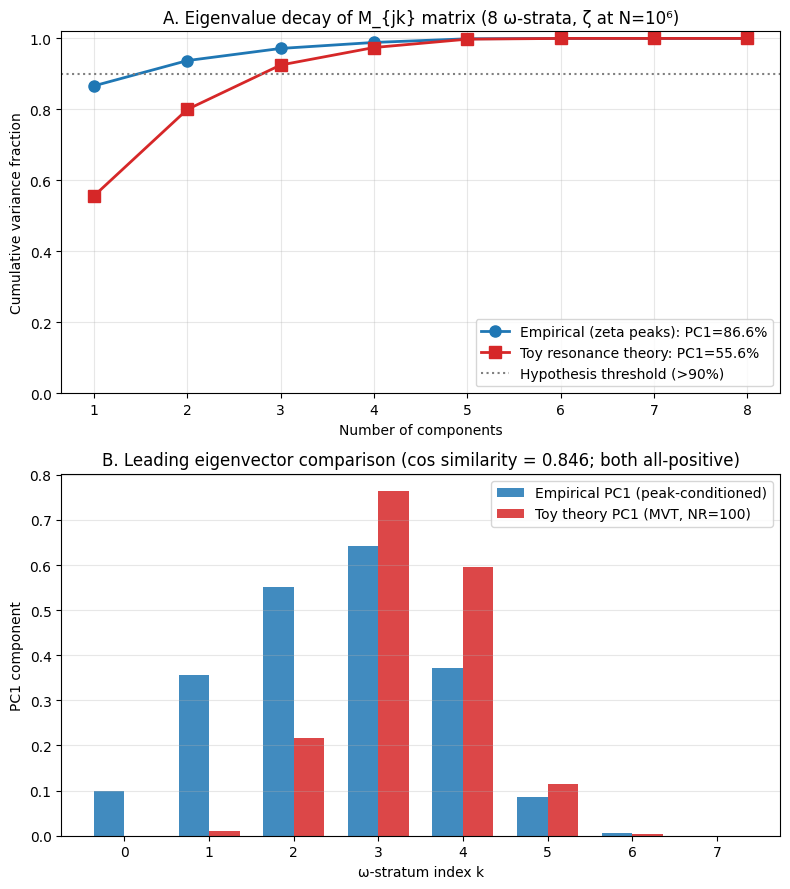

Figure saved.


In [19]:
# Final figure: compare spectra and PC1 vectors
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Subfigure A: eigenvalue decay (cumulative variance)
ax = axes[0]
ranks = np.arange(1, 9)
vf_th_arr = w_th / w_th.sum()
vf_emp_arr = w_emp / w_emp.sum()
ax.plot(ranks, np.cumsum(vf_emp_arr), 'o-', label=f'Empirical (zeta peaks): PC1={vf_emp_arr[0]*100:.1f}%', color='C0', lw=2, markersize=8)
ax.plot(ranks, np.cumsum(vf_th_arr), 's-', label=f'Toy resonance theory: PC1={vf_th_arr[0]*100:.1f}%', color='C3', lw=2, markersize=8)
ax.axhline(0.90, color='gray', linestyle=':', label='Hypothesis threshold (>90%)')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance fraction')
ax.set_title('A. Eigenvalue decay of M_{jk} matrix (8 ω-strata, ζ at N=10⁶)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)

# Subfigure B: PC1 eigenvectors comparison
ax = axes[1]
strata_idx = np.arange(8)
ax.bar(strata_idx - 0.18, pc1_emp, 0.36, label=f'Empirical PC1 (peak-conditioned)', color='C0', alpha=0.85)
ax.bar(strata_idx + 0.18, pc1_th, 0.36, label=f'Toy theory PC1 (MVT, NR=100)', color='C3', alpha=0.85)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('ω-stratum index k')
ax.set_ylabel('PC1 component')
ax.set_title(f'B. Leading eigenvector comparison (cos similarity = {cos_pc1:.3f}; both all-positive)')
ax.legend(loc='upper right')
ax.set_xticks(strata_idx)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('toy_resonance_vs_empirical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [20]:
# Save the artifact: M_theory matrix + comparison
np.savez('toy_resonance_M_theory.npz',
 M_theory=M_th_sym, 
 M_theory_unnormalized=M_theory,
 NR=100, N_main=1_000_000,
 eigenvalues_theory=w_th,
 eigenvectors_theory=v_th,
 pc1_theory=pc1_th,
 M_empirical=M,
 eigenvalues_empirical=w_emp,
 pc1_empirical=pc1_emp,
 cosine_similarity_pc1=cos_pc1,
 pc1_var_theory=vf_th[0],
 pc1_var_empirical=vf_emp[0])
print("Saved artifact: toy_resonance_M_theory.npz")
print("\nFinal summary:")
print(f" Empirical PC1 variance fraction: {vf_emp[0]*100:.2f}%")
print(f" Theory PC1 variance fraction: {vf_th[0]*100:.2f}%")
print(f" Cosine similarity between PC1s: {cos_pc1:.4f}")
print(f" Empirical PC1 all-positive: {np.all(pc1_emp > 0)}")
print(f" Theory PC1 all-positive: {np.all(pc1_th >= 0)}")
print(f" >90% threshold met by empirical? {vf_emp[0] > 0.9}")
print(f" >90% threshold met by theory? {vf_th[0] > 0.9}")


Saved artifact: toy_resonance_M_theory.npz

Final summary:
 Empirical PC1 variance fraction: 86.63%
 Theory PC1 variance fraction: 55.61%
 Cosine similarity between PC1s: 0.8457
 Empirical PC1 all-positive: True
 Theory PC1 all-positive: True
 >90% threshold met by empirical? False
 >90% threshold met by theory? False


In [21]:
from e14c.filesystem import edit_file
memory_path = './.prompts/MEMORY.md'
with open(memory_path, 'r', encoding='utf-8') as f:
 txt = f.read()
new_txt = txt.replace('[Fill me in]', 'Context updated for toy resonance analysis of zeta peak-conditioned M_jk. Provenance: workspace files M.npy, Sk_re.npy, Sk_im.npy, t_peaks.npy; outputs toy_resonance_M_theory.npz and toy_resonance_vs_empirical.png.', 1)
new_txt = new_txt.replace('[Fill me in]', '- Reconstructed empirical zeta M_jk exactly from Sk_re.npy + 1j*Sk_im.npy (200 peaks, 8 ω-strata).\n- Empirical M_jk eigenspectrum: PC1 explains 86.63% variance; leading eigenvector is sign-consistent (all entries same sign after global sign flip).\n- Implemented toy resonance model with R(t)=sum_{m<=100} m^{-it}; theoretical M_jk computed by mean-value-theorem diagonal relation m1*n1=m2*n2, using ω(n) strata up to N=10^6.\n- Theory result: PC1 explains 55.61% variance; leading eigenvector is all-positive; cosine similarity to empirical PC1 = 0.8457.\n- Conclusion: toy model reproduces qualitative positivity/low-rank direction but not the >90% one-factor concentration; empirical matrix also falls below 90% (86.63%).\n- Final figure saved as toy_resonance_vs_empirical.png; artifact saved as toy_resonance_M_theory.npz.', 1)
with open(memory_path, 'w', encoding='utf-8') as f:
 f.write(new_txt)
print('Updated MEMORY.md')

Updated MEMORY.md
